# 🛒 E-Commerce Customer Churn — Exploratory Data Analysis
**Data Source:** MariaDB Export  
**Dataset:** 50,000 customers × 25 features  
**Goal:** Understand patterns that drive customer churn


## 1. Imports & Setup

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

# Global style
sns.set_theme(style='whitegrid', palette='Set2')
plt.rcParams['figure.dpi'] = 100
plt.rcParams['axes.titlesize'] = 13
plt.rcParams['axes.labelsize'] = 11

## 2. Load Data

In [2]:
import glob, os

# Auto-find the CSV anywhere under the current working directory
matches = glob.glob('**/*churn*.csv', recursive=True) + glob.glob('**/*ecommerce*.csv', recursive=True)

if matches:
    csv_path = matches[0]
    print(f'Found: {csv_path}')
else:
    # Fallback: enter path manually
    csv_path = input('CSV not found automatically. Enter full path: ')

df = pd.read_csv(csv_path)

num_cols = df.select_dtypes(include='number').columns.drop('Churned').tolist()
cat_cols = ['Gender', 'Country', 'Signup_Quarter']

print(f"Rows   : {df.shape[0]:,}")
print(f"Columns: {df.shape[1]}")
df.head()

Found: customer churn\churn-pred-pipeline\dataset\ecommerce_customer_churn_dataset.csv
Rows   : 50,000
Columns: 25


,Age,Gender,Country,City,Membership_Years,Login_Frequency,Session_Duration_Avg,Pages_Per_Session,Cart_Abandonment_Rate,Wishlist_Items,...,Email_Open_Rate,Customer_Service_Calls,Product_Reviews_Written,Social_Media_Engagement_Score,Mobile_App_Usage,Payment_Method_Diversity,Lifetime_Value,Credit_Balance,Churned,Signup_Quarter
0,43.0,Male,France,Marseille,2.9,14.0,27.4,6.0,50.6,3.0,...,17.9,9.0,4.0,16.3,20.8,1.0,953.33,2278.0,0,Q1
1,36.0,Male,UK,Manchester,1.6,15.0,42.7,10.3,37.7,1.0,...,42.8,7.0,3.0,NaN,23.3,3.0,1067.47,3028.0,0,Q4
2,45.0,Female,Canada,Vancouver,2.9,10.0,24.8,1.6,70.9,1.0,...,0.0,4.0,1.0,NaN,8.8,NaN,1289.75,2317.0,0,Q4
3,56.0,Female,USA,New York,2.6,10.0,38.4,14.8,41.7,9.0,...,41.4,2.0,5.0,85.9,31.0,3.0,2340.92,2674.0,0,Q1
4,35.0,Male,India,Delhi,3.1,29.0,51.4,NaN,19.1,9.0,...,37.9,1.0,11.0,83.0,50.4,4.0,3041.29,5354.0,0,Q4


## 3. Data Overview

In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 50000 entries, 0 to 49999
Data columns (total 25 columns):
 #   Column                         Non-Null Count  Dtype  
---  ------                         --------------  -----  
 0   Age                            47505 non-null  float64
 1   Gender                         50000 non-null  object 
 2   Country                        50000 non-null  object 
 3   City                           50000 non-null  object 
 4   Membership_Years               50000 non-null  float64
 5   Login_Frequency                50000 non-null  float64
 6   Session_Duration_Avg           46601 non-null  float64
 7   Pages_Per_Session              47000 non-null  float64
 8   Cart_Abandonment_Rate          50000 non-null  float64
 9   Wishlist_Items                 46000 non-null  float64
 10  Total_Purchases                50000 non-null  float64
 11  Average_Order_Value            50000 non-null  float64
 12  Days_Since_Last_Purchase       47000 non-null 

In [4]:
df.describe().T.style.background_gradient(cmap='Blues', subset=['mean','std'])

,count,mean,std,min,25%,50%,75%,max
Age,47505.000000,37.802968,11.834668,5.000000,29.000000,38.000000,46.000000,200.000000
Membership_Years,50000.000000,2.984009,2.059105,0.100000,1.400000,2.500000,4.000000,10.000000
Login_Frequency,50000.000000,11.624660,7.810657,0.000000,6.000000,11.000000,17.000000,46.000000
Session_Duration_Avg,46601.000000,27.660754,10.871013,1.000000,19.700000,26.800000,34.700000,75.600000
Pages_Per_Session,47000.000000,8.737811,3.778220,1.000000,6.000000,8.400000,11.200000,24.100000
Cart_Abandonment_Rate,50000.000000,57.079973,16.282723,0.000000,46.400000,58.100000,68.700000,143.743350
Wishlist_Items,46000.000000,4.298391,3.189754,0.000000,2.000000,4.000000,6.000000,28.000000
Total_Purchases,50000.000000,13.111576,7.017312,-13.000000,8.000000,12.000000,17.000000,128.700000
Average_Order_Value,50000.000000,123.117330,175.569714,26.380000,87.050000,112.970000,144.440000,9666.379178
Days_Since_Last_Purchase,47000.000000,29.792872,29.695062,0.000000,9.000000,21.000000,41.000000,287.000000


## 4. Missing Values

                               Count  Percentage (%)
Social_Media_Engagement_Score   6000           12.00
Credit_Balance                  5500           11.00
Mobile_App_Usage                5000           10.00
Returns_Rate                    4491            8.98
Wishlist_Items                  4000            8.00
Discount_Usage_Rate             3500            7.00
Product_Reviews_Written         3500            7.00
Session_Duration_Avg            3399            6.80
Pages_Per_Session               3000            6.00
Days_Since_Last_Purchase        3000            6.00
Email_Open_Rate                 2528            5.06
Payment_Method_Diversity        2500            5.00
Age                             2495            4.99
Customer_Service_Calls           168            0.34


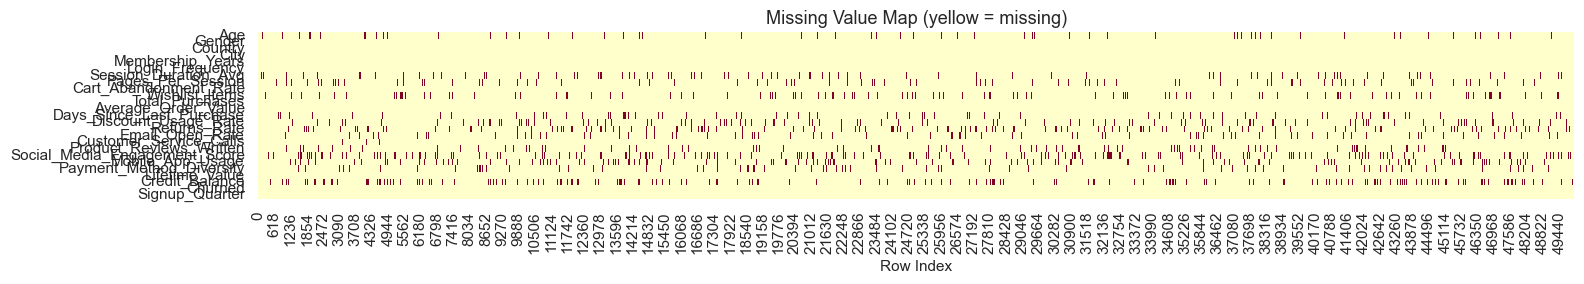

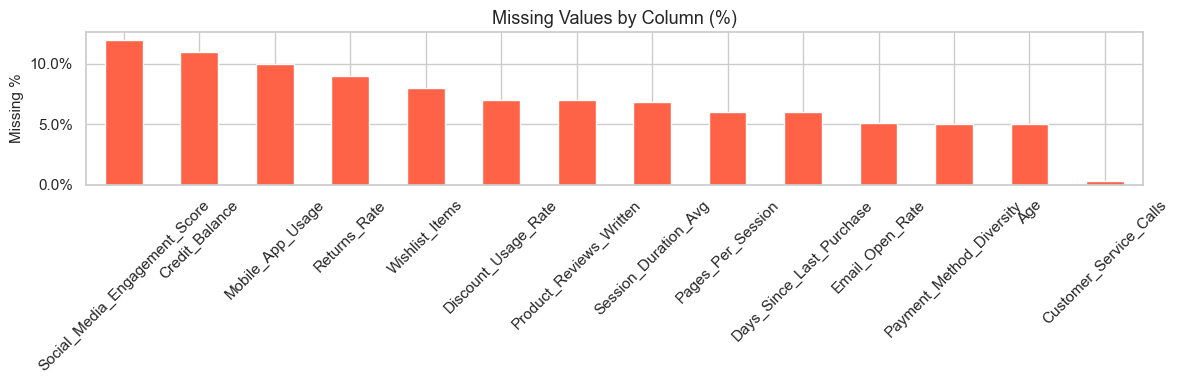

In [5]:
missing = df.isnull().sum()
missing_pct = (missing / len(df) * 100).round(2)
missing_df = pd.DataFrame({'Count': missing, 'Percentage (%)': missing_pct})
missing_df = missing_df[missing_df['Count'] > 0].sort_values('Percentage (%)', ascending=False)
print(missing_df)

# Heatmap of nulls
plt.figure(figsize=(16, 3))
sns.heatmap(df.isnull().T, cbar=False, yticklabels=True, cmap='YlOrRd')
plt.title('Missing Value Map (yellow = missing)')
plt.xlabel('Row Index')
plt.tight_layout()
plt.show()

# Bar chart
fig, ax = plt.subplots(figsize=(12, 4))
missing_pct[missing_pct > 0].sort_values(ascending=False).plot(kind='bar', ax=ax, color='tomato', edgecolor='white')
ax.set_title('Missing Values by Column (%)')
ax.set_ylabel('Missing %')
ax.yaxis.set_major_formatter(mtick.PercentFormatter())
ax.tick_params(axis='x', rotation=45)
plt.tight_layout()
plt.show()

## 5. Target Variable — Churn Distribution

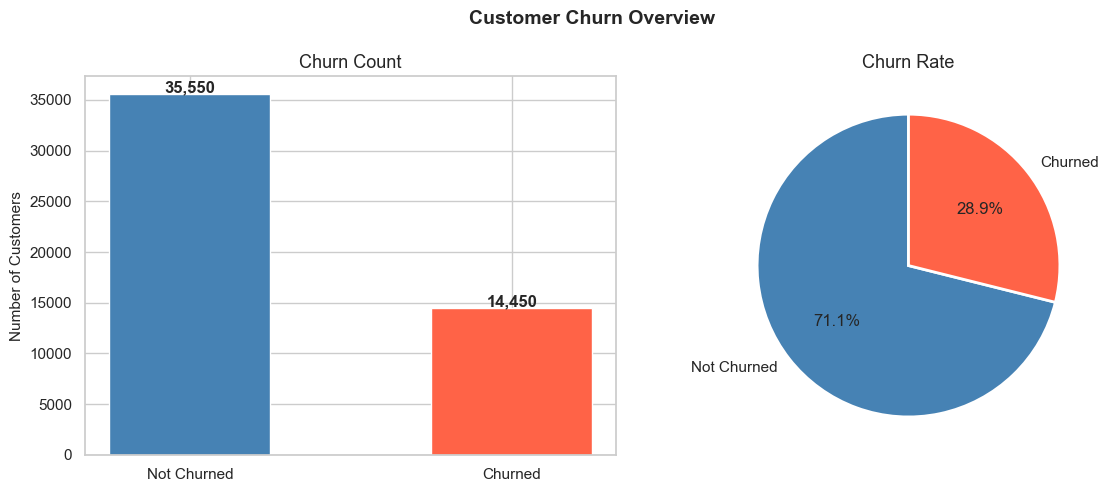

In [6]:
churn_labels = {0: 'Not Churned', 1: 'Churned'}
df['Churn_Label'] = df['Churned'].map(churn_labels)

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Count plot
order = ['Not Churned', 'Churned']
colors = ['steelblue', 'tomato']
counts = df['Churn_Label'].value_counts()[order]
axes[0].bar(order, counts, color=colors, edgecolor='white', width=0.5)
for i, (label, val) in enumerate(counts.items()):
    axes[0].text(i, val + 200, f'{val:,}', ha='center', fontweight='bold')
axes[0].set_title('Churn Count')
axes[0].set_ylabel('Number of Customers')

# Pie chart
axes[1].pie(counts, labels=order, autopct='%1.1f%%', colors=colors,
            startangle=90, wedgeprops={'edgecolor': 'white', 'linewidth': 2})
axes[1].set_title('Churn Rate')

plt.suptitle('Customer Churn Overview', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

## 6. Univariate Analysis — Numerical Features

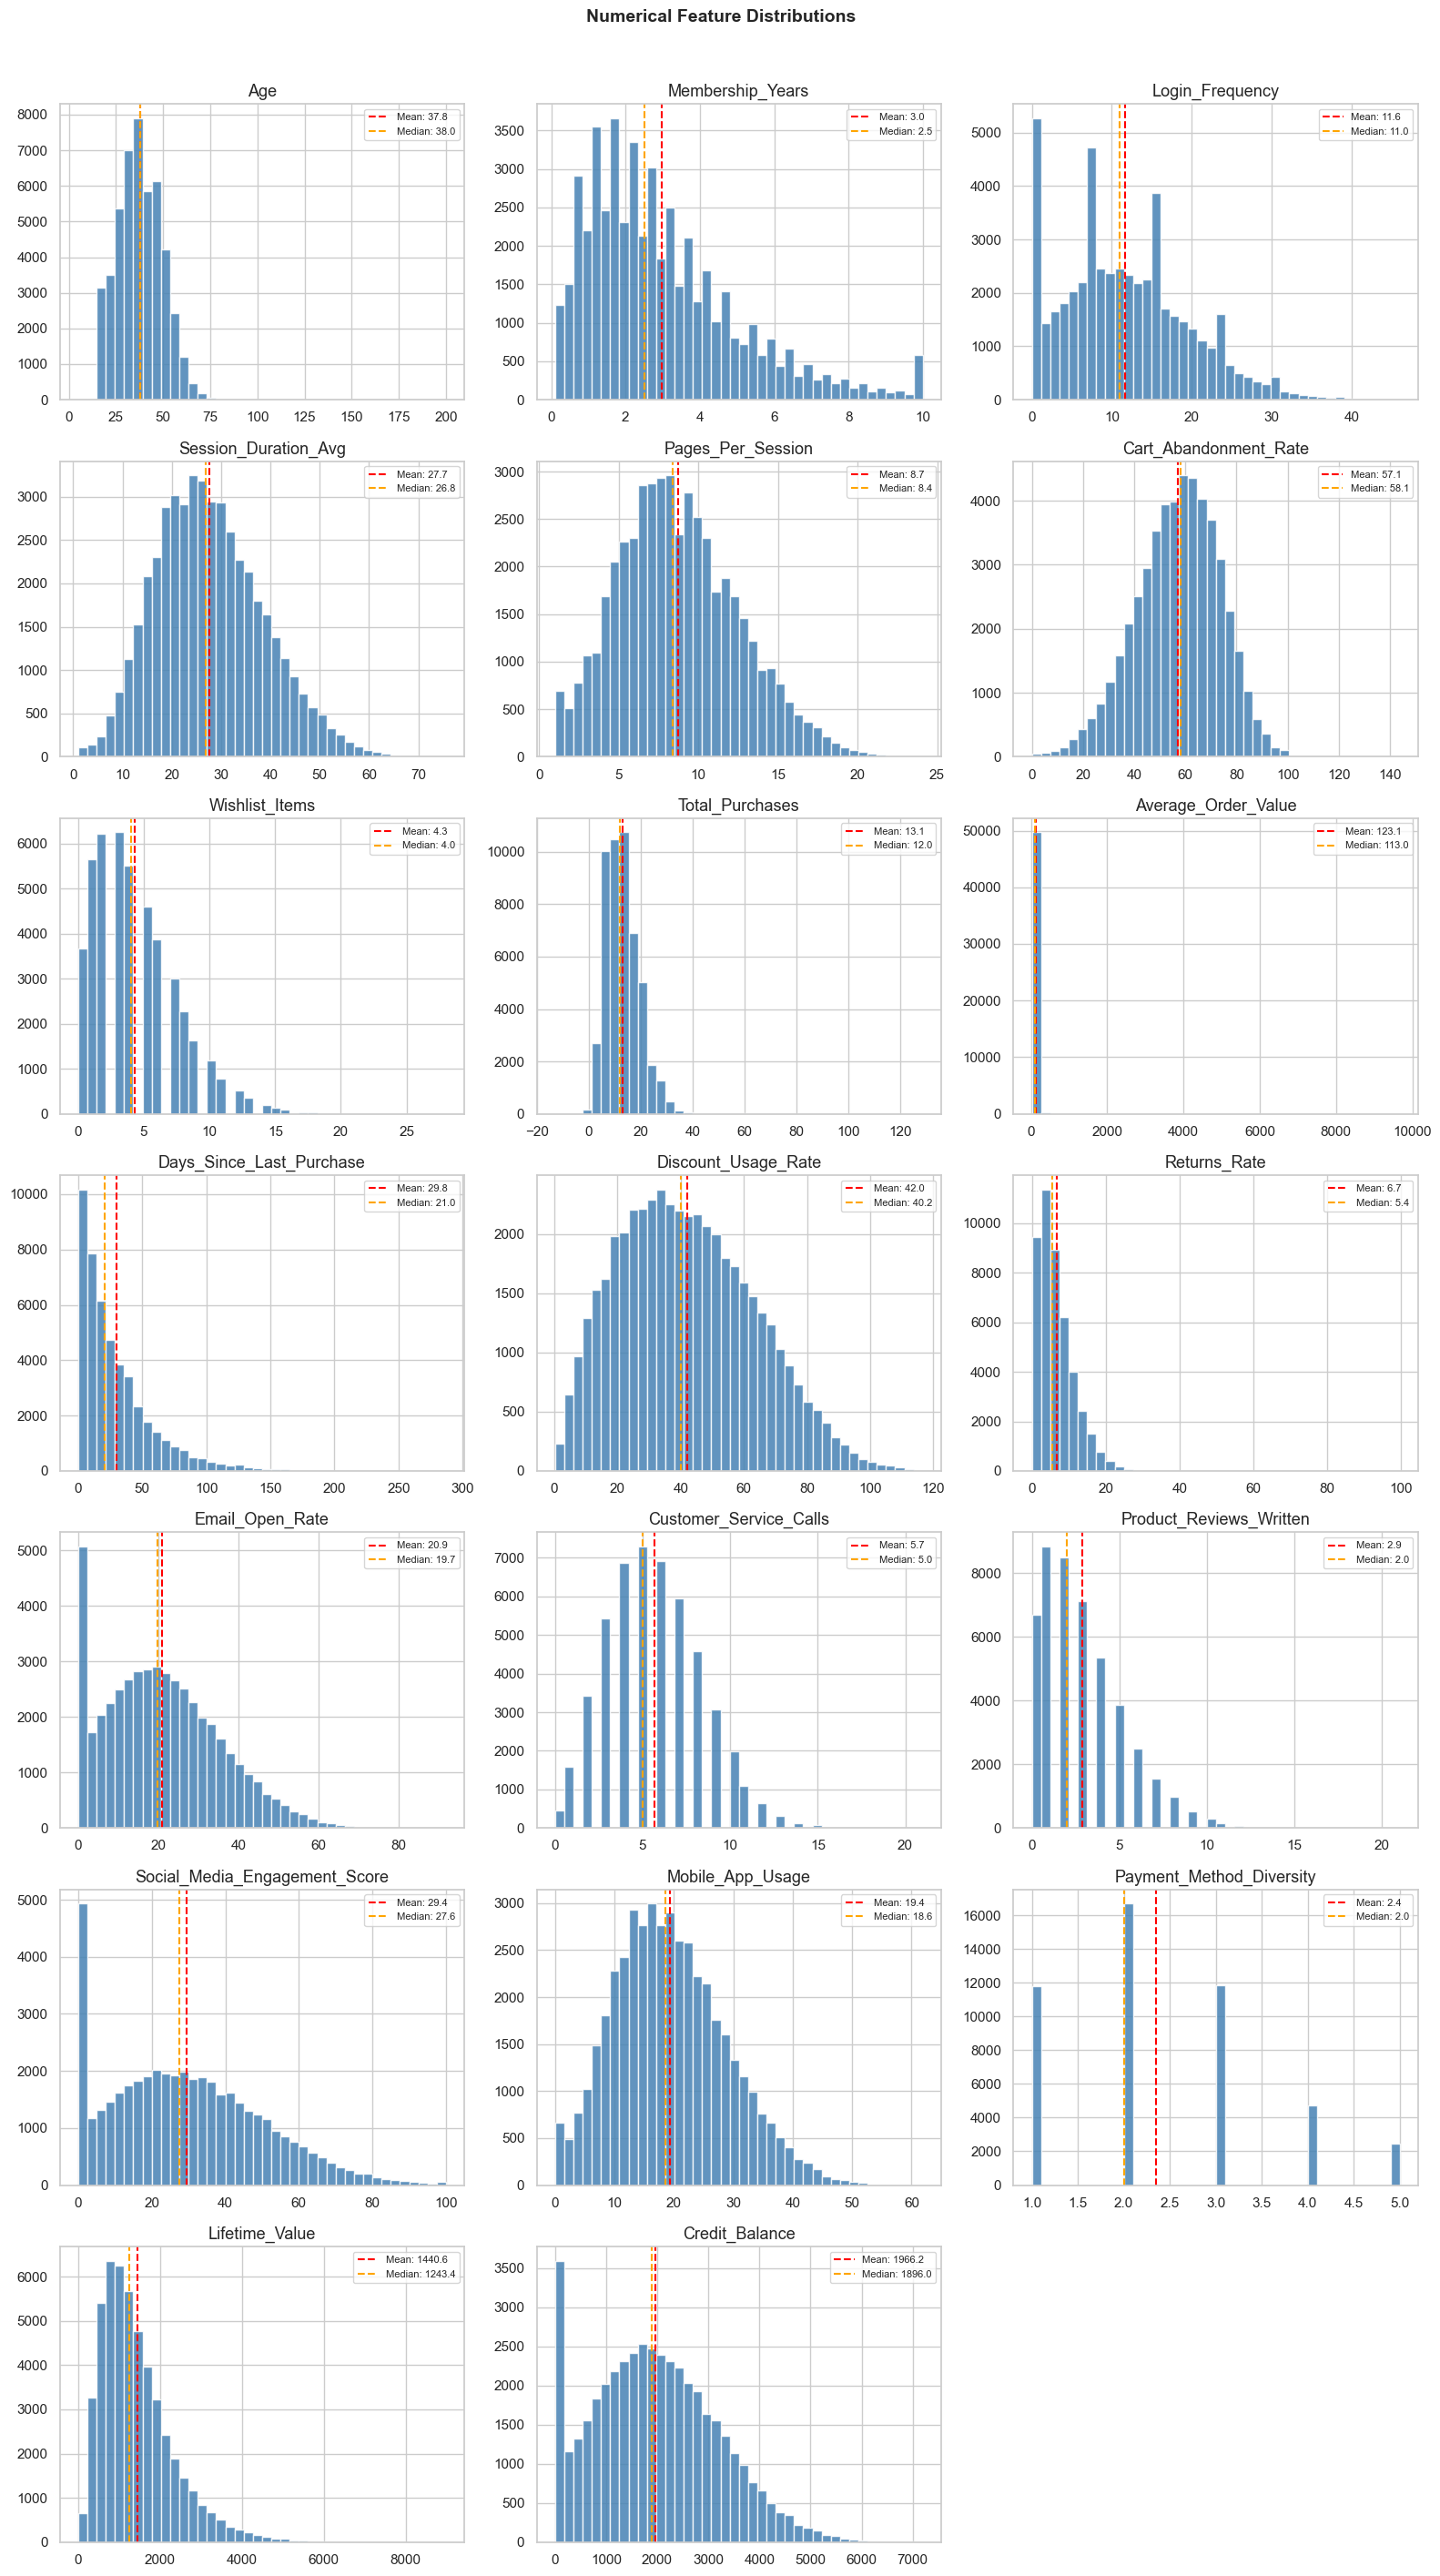

In [7]:
n = len(num_cols)
ncols = 3
nrows = (n + ncols - 1) // ncols

fig, axes = plt.subplots(nrows, ncols, figsize=(16, nrows * 4))
axes = axes.flatten()

for i, col in enumerate(num_cols):
    data = df[col].dropna()
    axes[i].hist(data, bins=40, color='steelblue', edgecolor='white', alpha=0.85)
    axes[i].axvline(data.mean(), color='red', linestyle='--', linewidth=1.5, label=f'Mean: {data.mean():.1f}')
    axes[i].axvline(data.median(), color='orange', linestyle='--', linewidth=1.5, label=f'Median: {data.median():.1f}')
    axes[i].set_title(col)
    axes[i].legend(fontsize=8)

for j in range(i+1, len(axes)):
    axes[j].set_visible(False)

plt.suptitle('Numerical Feature Distributions', fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

## 7. Univariate Analysis — Categorical Features

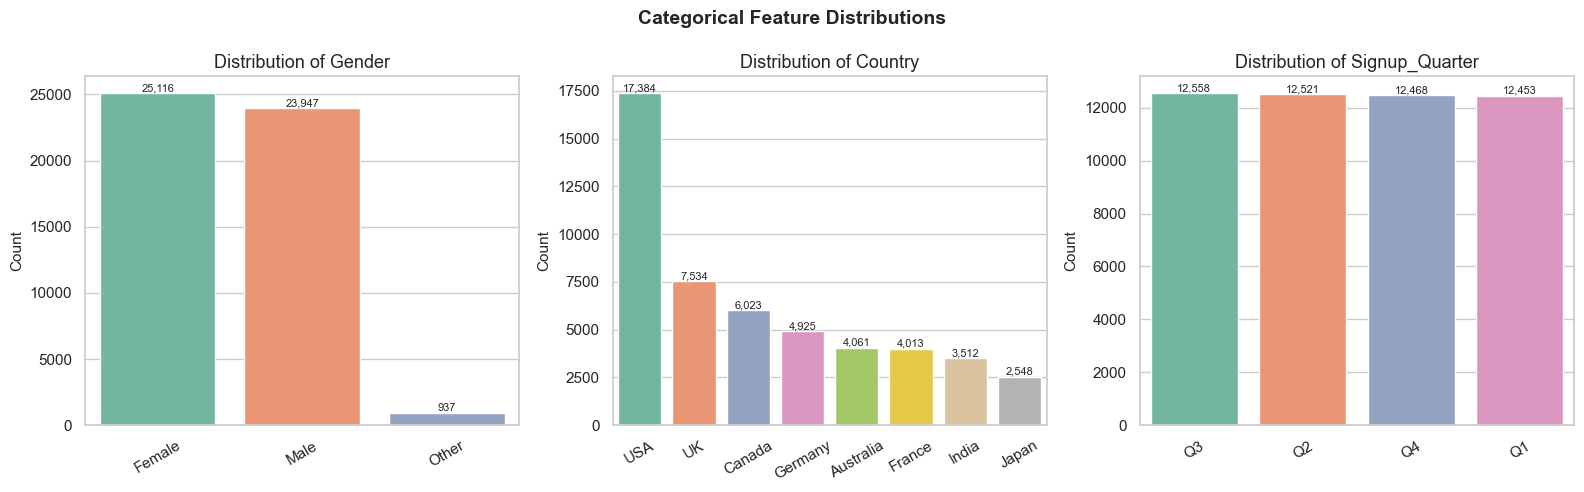

In [8]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

for ax, col in zip(axes, cat_cols):
    counts = df[col].value_counts()
    sns.barplot(x=counts.index, y=counts.values, ax=ax, palette='Set2')
    ax.set_title(f'Distribution of {col}')
    ax.set_ylabel('Count')
    ax.set_xlabel('')
    ax.tick_params(axis='x', rotation=30)
    for p in ax.patches:
        ax.annotate(f'{int(p.get_height()):,}', (p.get_x() + p.get_width() / 2., p.get_height()),
                    ha='center', va='bottom', fontsize=8)

plt.suptitle('Categorical Feature Distributions', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

## 8. Bivariate Analysis — Box Plots (Churn vs Numerical)

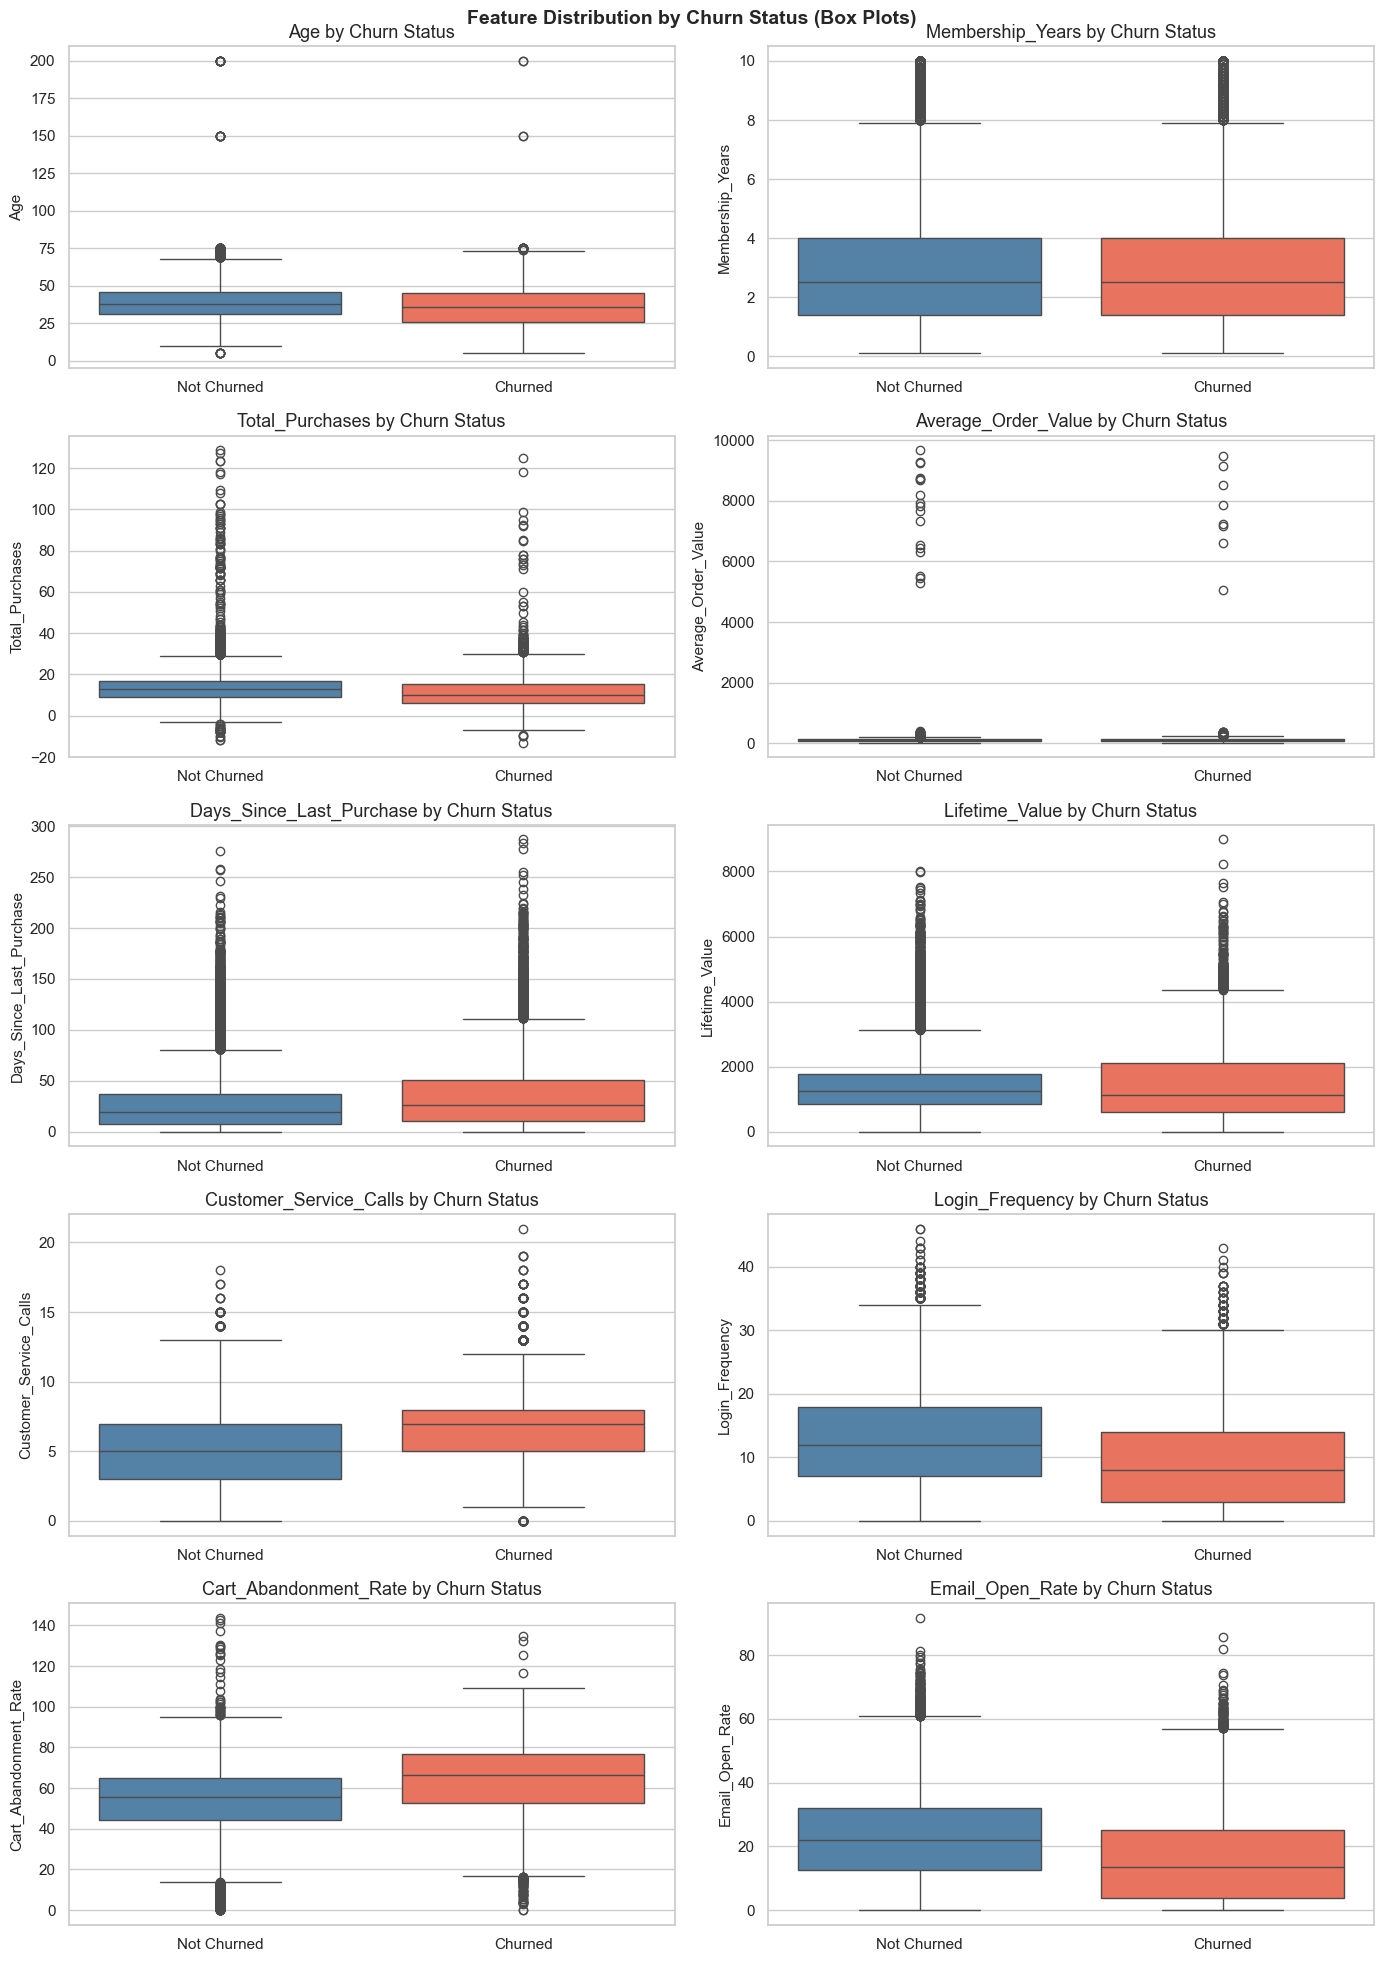

In [9]:
key_cols = ['Age', 'Membership_Years', 'Total_Purchases', 'Average_Order_Value',
            'Days_Since_Last_Purchase', 'Lifetime_Value', 'Customer_Service_Calls',
            'Login_Frequency', 'Cart_Abandonment_Rate', 'Email_Open_Rate']

ncols = 2
nrows = (len(key_cols) + 1) // 2

fig, axes = plt.subplots(nrows, ncols, figsize=(14, nrows * 4))
axes = axes.flatten()

for i, col in enumerate(key_cols):
    sns.boxplot(data=df, x='Churn_Label', y=col, ax=axes[i],
                palette={'Not Churned': 'steelblue', 'Churned': 'tomato'},
                order=['Not Churned', 'Churned'])
    axes[i].set_title(f'{col} by Churn Status')
    axes[i].set_xlabel('')

for j in range(i+1, len(axes)):
    axes[j].set_visible(False)

plt.suptitle('Feature Distribution by Churn Status (Box Plots)', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

## 9. Violin Plots — Churn vs Key Features

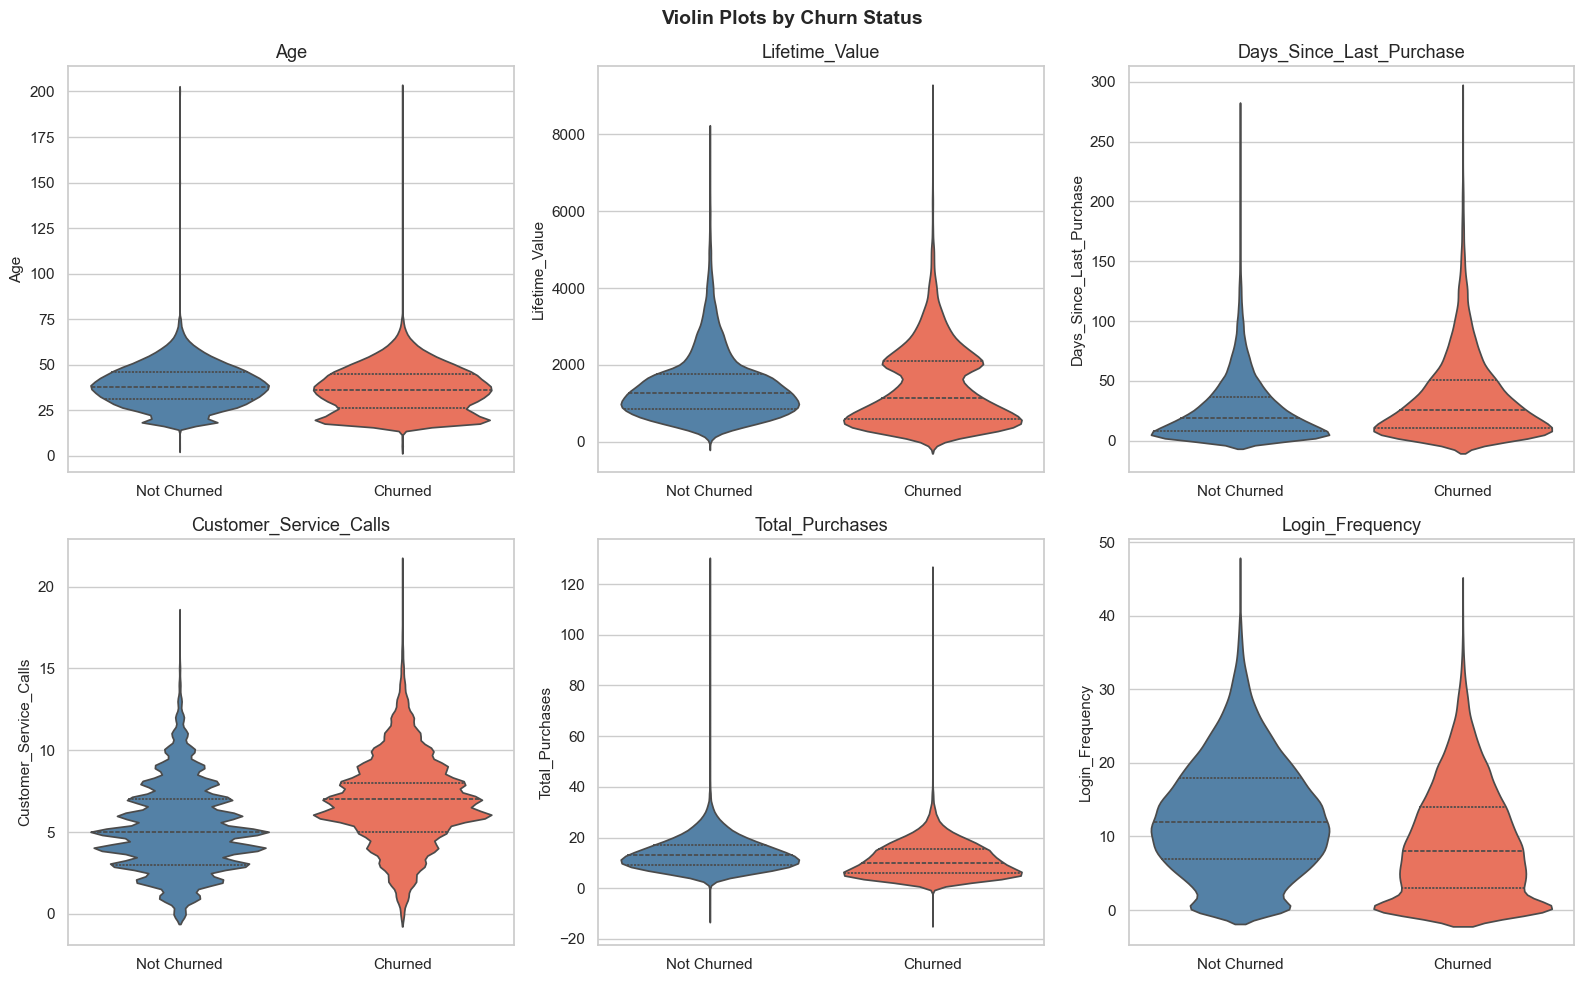

In [10]:
violin_cols = ['Age', 'Lifetime_Value', 'Days_Since_Last_Purchase',
               'Customer_Service_Calls', 'Total_Purchases', 'Login_Frequency']

fig, axes = plt.subplots(2, 3, figsize=(16, 10))
axes = axes.flatten()

for i, col in enumerate(violin_cols):
    sns.violinplot(data=df, x='Churn_Label', y=col, ax=axes[i],
                   palette={'Not Churned': 'steelblue', 'Churned': 'tomato'},
                   order=['Not Churned', 'Churned'], inner='quartile')
    axes[i].set_title(f'{col}')
    axes[i].set_xlabel('')

plt.suptitle('Violin Plots by Churn Status', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

## 10. KDE Plots — Churn vs Non-Churn Overlap

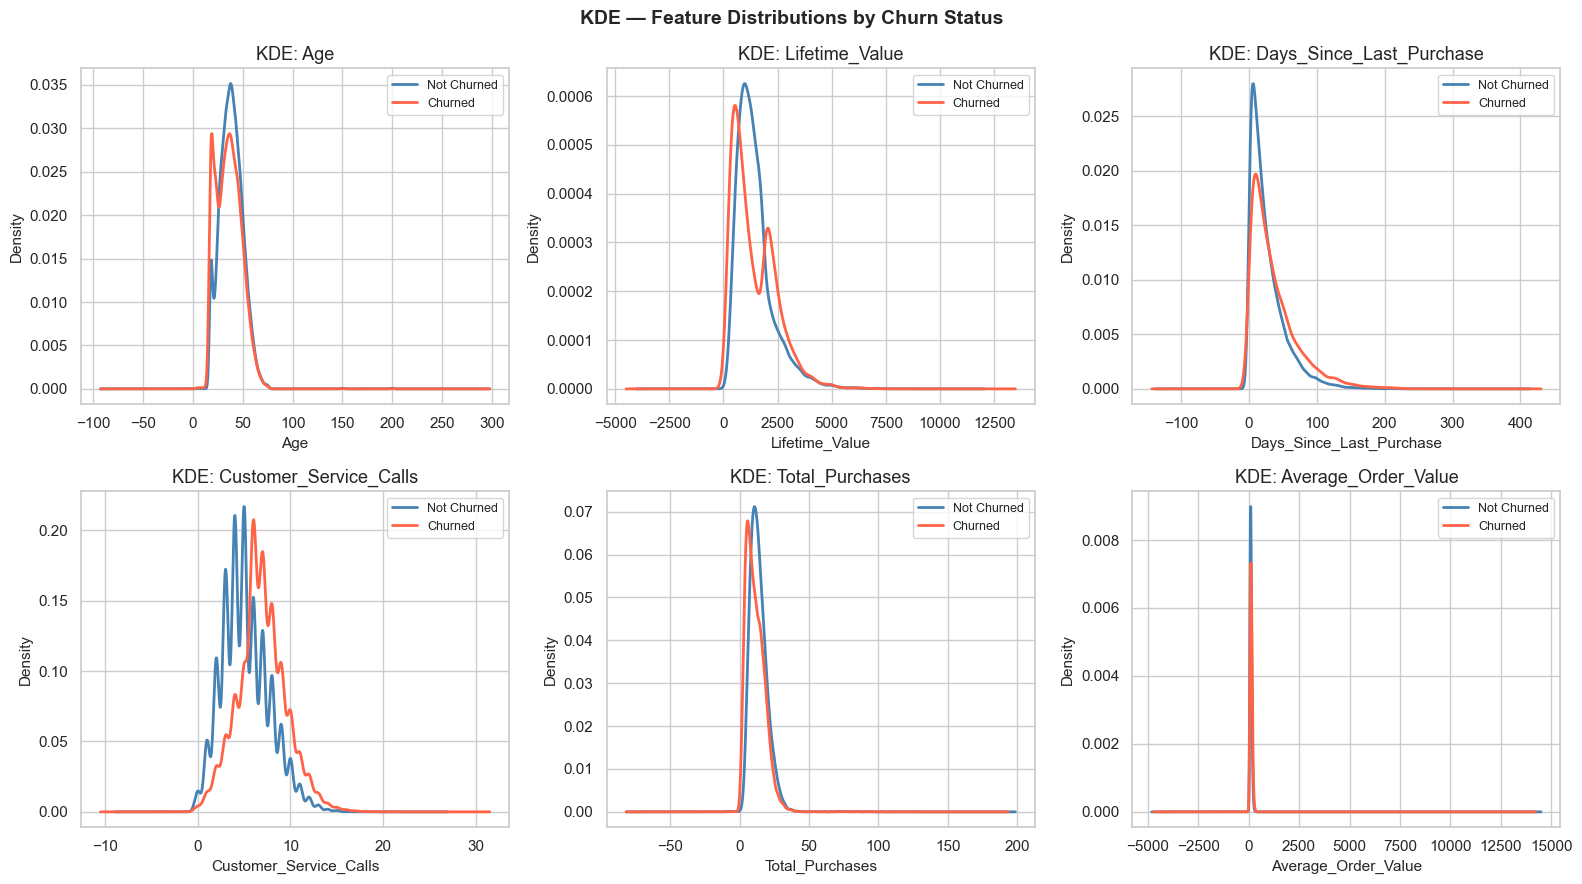

In [11]:
kde_cols = ['Age', 'Lifetime_Value', 'Days_Since_Last_Purchase',
            'Customer_Service_Calls', 'Total_Purchases', 'Average_Order_Value']

fig, axes = plt.subplots(2, 3, figsize=(16, 9))
axes = axes.flatten()

for i, col in enumerate(kde_cols):
    for label, color in [('Not Churned', 'steelblue'), ('Churned', 'tomato')]:
        data = df[df['Churn_Label'] == label][col].dropna()
        data.plot.kde(ax=axes[i], label=label, color=color, linewidth=2)
    axes[i].set_title(f'KDE: {col}')
    axes[i].set_xlabel(col)
    axes[i].legend(fontsize=9)

plt.suptitle('KDE — Feature Distributions by Churn Status', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

## 11. Categorical Features vs Churn

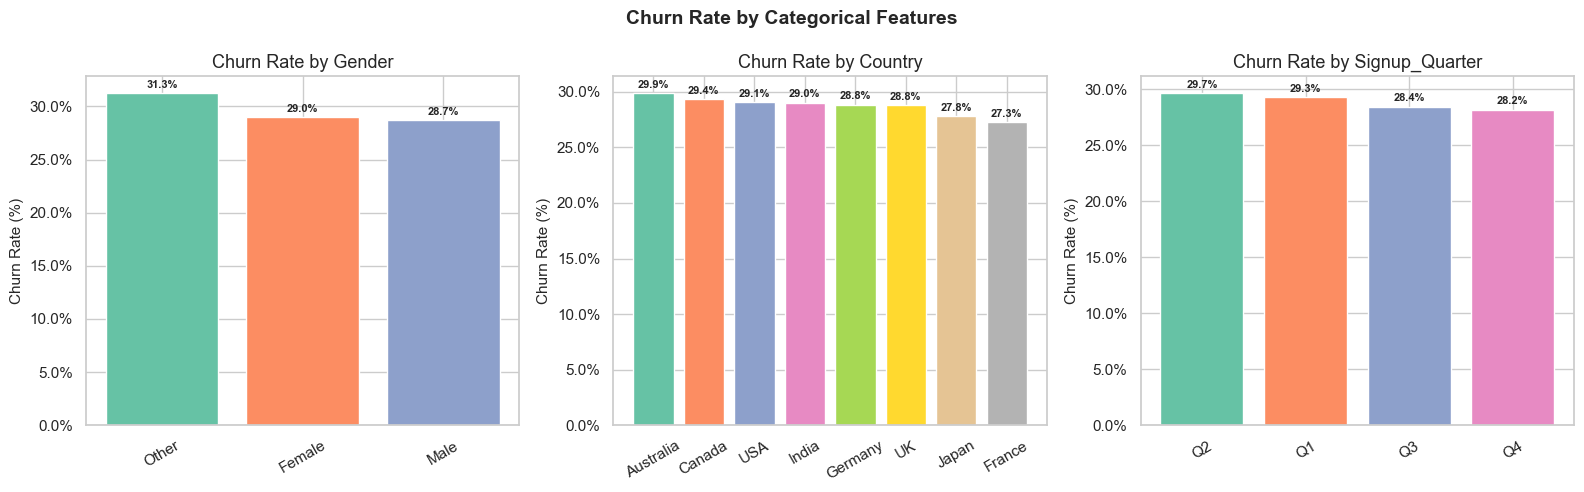

In [12]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

for ax, col in zip(axes, cat_cols):
    churn_rate = df.groupby(col)['Churned'].mean().sort_values(ascending=False)
    bars = ax.bar(churn_rate.index, churn_rate.values * 100,
                  color=sns.color_palette('Set2', len(churn_rate)), edgecolor='white')
    ax.set_title(f'Churn Rate by {col}')
    ax.set_ylabel('Churn Rate (%)')
    ax.yaxis.set_major_formatter(mtick.PercentFormatter())
    ax.tick_params(axis='x', rotation=30)
    for bar in bars:
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.3,
                f'{bar.get_height():.1f}%', ha='center', va='bottom', fontsize=8, fontweight='bold')

plt.suptitle('Churn Rate by Categorical Features', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

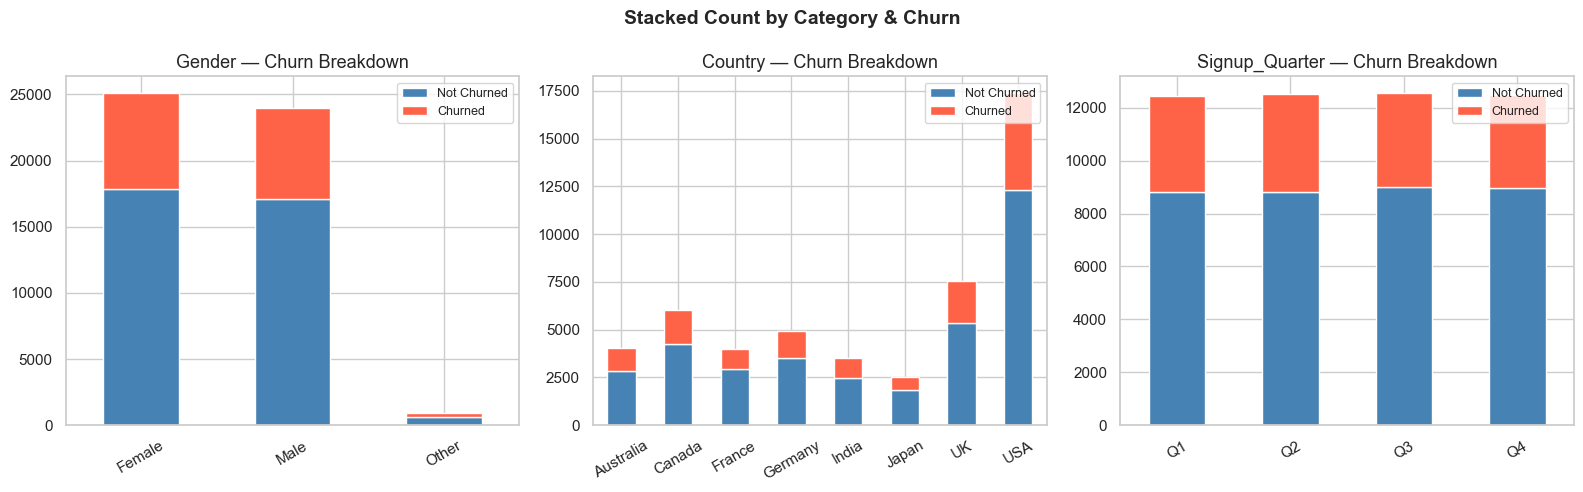

In [13]:
# Stacked bar — count breakdown
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

for ax, col in zip(axes, cat_cols):
    ct = pd.crosstab(df[col], df['Churn_Label'])
    ct = ct[['Not Churned', 'Churned']]
    ct.plot(kind='bar', stacked=True, ax=ax, color=['steelblue', 'tomato'], edgecolor='white')
    ax.set_title(f'{col} — Churn Breakdown')
    ax.set_xlabel('')
    ax.tick_params(axis='x', rotation=30)
    ax.legend(loc='upper right', fontsize=9)

plt.suptitle('Stacked Count by Category & Churn', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

## 12. Correlation Heatmap

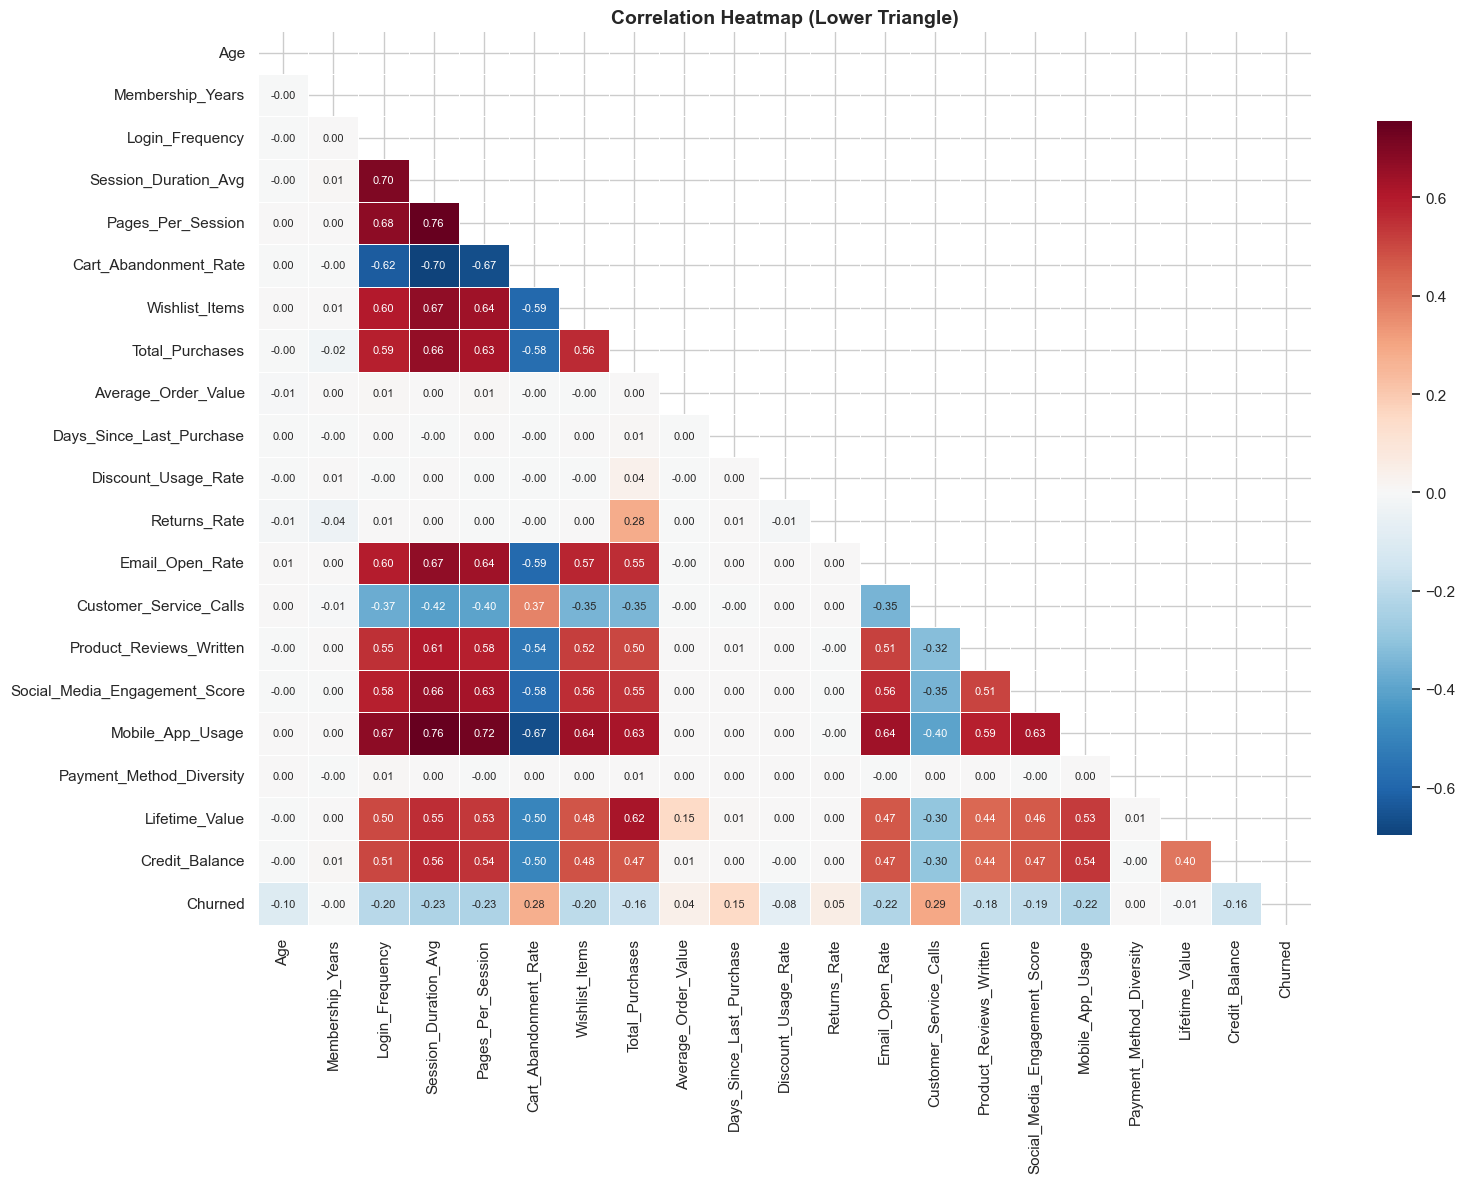

In [14]:
corr = df[num_cols + ['Churned']].corr()

plt.figure(figsize=(16, 12))
mask = np.triu(np.ones_like(corr, dtype=bool))   # upper triangle mask
sns.heatmap(corr, mask=mask, annot=True, fmt='.2f', cmap='RdBu_r',
            center=0, linewidths=0.5, annot_kws={'size': 8},
            cbar_kws={'shrink': 0.8})
plt.title('Correlation Heatmap (Lower Triangle)', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

## 13. Feature Correlations with Churn

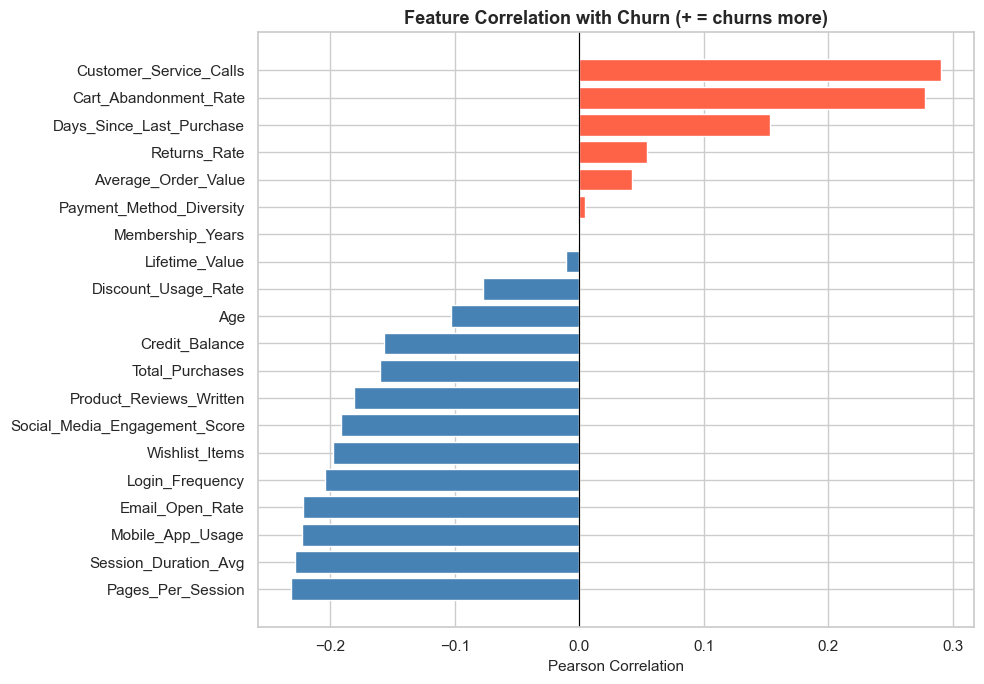

In [15]:
churn_corr = corr['Churned'].drop('Churned').sort_values()

colors = ['tomato' if v > 0 else 'steelblue' for v in churn_corr]

plt.figure(figsize=(10, 7))
bars = plt.barh(churn_corr.index, churn_corr.values, color=colors, edgecolor='white')
plt.axvline(0, color='black', linewidth=0.8)
plt.title('Feature Correlation with Churn (+ = churns more)', fontsize=13, fontweight='bold')
plt.xlabel('Pearson Correlation')
plt.tight_layout()
plt.show()

## 14. Pairplot — Top Features

In [ ]:
top_feats = ['Age', 'Lifetime_Value', 'Days_Since_Last_Purchase',
             'Customer_Service_Calls', 'Total_Purchases', 'Churned']

pair_df = df[top_feats].dropna()
pair_df['Churn_Label'] = pair_df['Churned'].map({0: 'Not Churned', 1: 'Churned'})

g = sns.pairplot(pair_df.drop('Churned', axis=1), hue='Churn_Label',
                 palette={'Not Churned': 'steelblue', 'Churned': 'tomato'},
                 plot_kws={'alpha': 0.4, 's': 15}, diag_kind='kde')
g.fig.suptitle('Pairplot — Top Features by Churn', y=1.01, fontsize=13, fontweight='bold')
plt.show()

## 15. Outlier Detection

In [ ]:
outlier_cols = ['Total_Purchases', 'Average_Order_Value', 'Customer_Service_Calls'++,
                'Lifetime_Value', 'Days_Since_Last_Purchase', 'Credit_Balance']

fig, axes = plt.subplots(2, 3, figsize=(16, 9))
axes = axes.flatten()

for i, col in enumerate(outlier_cols):
    sns.boxplot(y=df[col].dropna(), ax=axes[i], color='lightcoral', width=0.4)
    axes[i].set_title(f'Outliers: {col}')

plt.suptitle('Outlier Detection (Box Plots)', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

## 16. EDA Summary

| Metric | Value |
|--------|-------|
| Total Customers | 50,000 |
| Features | 25 |
| Churn Rate | ~28.9% |
| Missing Values | Present across most numeric columns |
| Numeric Features | 20 |
| Categorical Features | 4 |

### Key Findings
- **Churn is imbalanced** — ~29% churned vs 71% retained; consider resampling before modelling.
- **Days Since Last Purchase** — churned customers tend to have gone longer without a purchase.
- **Customer Service Calls** — higher call frequency correlates with higher churn.
- **Lifetime Value & Total Purchases** — lower in churned segment.
- **Demographics** — Gender and Country show mild differences in churn rate.
- **Missing values** must be imputed before building ML models.
